# Analysis of complexity of MSPSP with results from MaxSAT solver

In [34]:

!pwd

/Users/wilberquito/repos/mspsp-all/mspsp-stats/notebooks/smtapi/solving-complexity-relation/maxsat/0100


In [35]:
import os
import seaborn as sns
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional
from pathlib import Path
from pprint import pprint

ROOT = Path().resolve().parent.parent.parent.parent.parent
print(ROOT)

DATA = ROOT / "data"
FIGURES = ROOT / "figures"

pipe = "smtapi"

DIRS = {
    "data": {
        "wandb": DATA / "wandb" / pipe,
        "analysis": DATA / "analysis" / pipe / "instances",
    },
    "figures": FIGURES / pipe,
}

# Set working directory to the notebook's location

pprint(DIRS)

/Users/wilberquito/repos/mspsp-all/mspsp-stats
{'data': {'analysis': PosixPath('/Users/wilberquito/repos/mspsp-all/mspsp-stats/data/analysis/smtapi/instances'),
          'wandb': PosixPath('/Users/wilberquito/repos/mspsp-all/mspsp-stats/data/wandb/smtapi')},
 'figures': PosixPath('/Users/wilberquito/repos/mspsp-all/mspsp-stats/figures/smtapi')}


In [36]:
result_maxsat_csv = f"{DIRS['data']['wandb']}/smtapi-MSPSP__ma_grups@f=maxsat__s=evalmaxsat__i=i1=0,i2=1,i3=0,i4=0.csv"
df_maxsat = pd.read_csv(result_maxsat_csv)
df_maxsat.shape

(1142, 21)

In [37]:
df_maxsat.head(2)

,Unnamed: 0,name,formalism,implied_1,implied_2,implied_3,implied_4,inline_config,mspsp_instance,solver,...,encoder.real_time,encoder.sys_time,encoder.user_time,makespan,model,slurm.timeout,solution_status,solver.real_time,solver.sys_time,solver.user_time
0,0,doctor-dukat-1,maxsat,0.0,1.0,0.0,0.0,"f=maxsat__s=evalmaxsat__i=i1=0,i2=1,i3=0,i4=0",./modules/rcpsp-instances/MSPSP/set-1a/inst_se...,evalmaxsat,...,0.2,0.1,0.09,61.0,v S_0:0; S_1:29; S_2:0; S_3:0; S_4:9; S_5:12; ...,False,OPTIMUM_FOUND,0.33,0.00,0.25
1,1,ensign-quark-2,maxsat,0.0,1.0,0.0,0.0,"f=maxsat__s=evalmaxsat__i=i1=0,i2=1,i3=0,i4=0",./modules/rcpsp-instances/MSPSP/set-1a/inst_se...,evalmaxsat,...,0.2,0.1,0.09,66.0,v S_0:0; S_1:10; S_2:0; S_3:0; S_4:10; S_5:28;...,False,OPTIMUM_FOUND,0.11,0.01,0.10


In [38]:
hardness_instances_csv = f"{DIRS['data']['analysis']}/mspsp_stats.csv"
df_hardness = pd.read_csv(hardness_instances_csv)
df_hardness.shape

(1142, 10)

In [39]:
df_hardness.head(2)

,family,n_activities,n_skills,n_resources,n_precedences,skill_factor,modified_resource_strength,network_complexity,network_density,mspsp_instance
0,set-1a,22,4,10,31,0.5,0.125,1.409091,0.0671,./modules/rcpsp-instances/MSPSP/set-1a/inst_se...
1,set-1a,22,4,10,31,0.5,0.125,1.409091,0.0671,./modules/rcpsp-instances/MSPSP/set-1a/inst_se...


In [40]:
# Merge dataframes on `mspsp_instance`
df_merged = pd.merge(df_maxsat, df_hardness, on="mspsp_instance", how="inner")
df_merged.shape

(1142, 30)

In [41]:
df_merged.columns

Index(['Unnamed: 0', 'name', 'formalism', 'implied_1', 'implied_2',
       'implied_3', 'implied_4', 'inline_config', 'mspsp_instance', 'solver',
       'solving_timeout_s', 'encoder.real_time', 'encoder.sys_time',
       'encoder.user_time', 'makespan', 'model', 'slurm.timeout',
       'solution_status', 'solver.real_time', 'solver.sys_time',
       'solver.user_time', 'family', 'n_activities', 'n_skills', 'n_resources',
       'n_precedences', 'skill_factor', 'modified_resource_strength',
       'network_complexity', 'network_density'],
      dtype='object')

In [42]:
# Generate bitmask for implied
def add_implied_column(df: pd.DataFrame, check: bool) -> pd.DataFrame:
    # Creamos un ID único para la configuración de implied constraints

    impl_cols = [c for c in df.columns if "implied_" in c]
    df["implied_bitmask"] = df[impl_cols].apply(
        lambda x: "".join(["1" if val else "0" for val in x]), axis=1
    )

    if check:
        config_count = df["implied_bitmask"].value_counts()
        s = config_count.iloc[0]
        diff_n_count = 0
        logger: list[str] = list()

        for i, c in enumerate(config_count):
            if c != s:
                diff_n_count += 1
                logger.append(config_count.index[i])

        if diff_n_count > 0:
            print(
                f"WARNING: Configuration count mismatch: {diff_n_count} configurations have a different count than the first one"
            )
            print("Mismatched configurations:", logger)

    return df


def add_logarithmic_time(df: pd.DataFrame) -> pd.DataFrame:
    df["solver.log_real_time"] = df["solver.real_time"].apply(
        lambda x: np.log10(x + 1e-6)
    )
    return df


df_merged = add_implied_column(df_merged, check=True)
df_merged = add_logarithmic_time(df_merged)

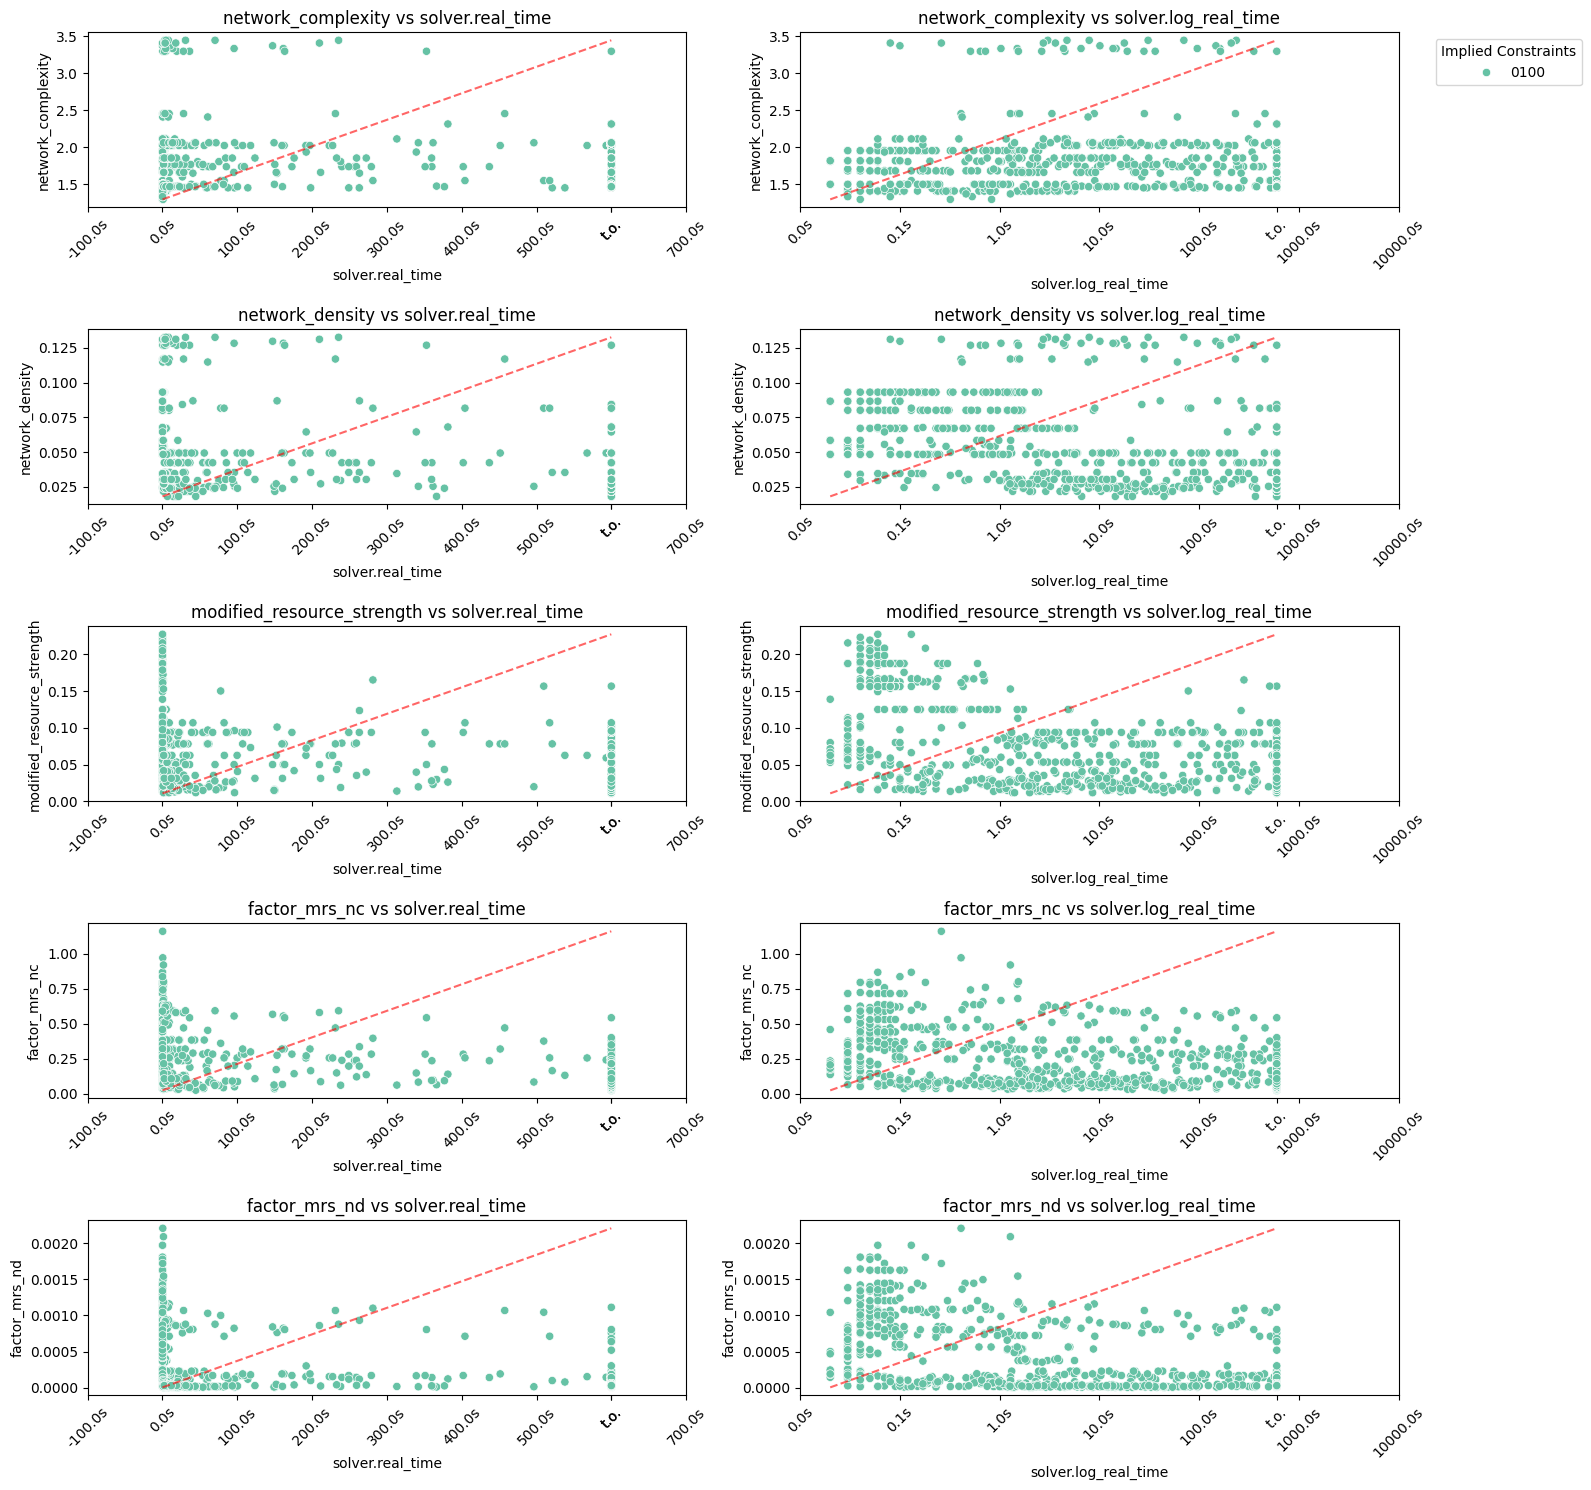

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare data
df_merged["factor_mrs_nc"] = df_merged["modified_resource_strength"] * (
    df_merged["network_complexity"] ** 2
)
df_merged["factor_mrs_nd"] = df_merged["modified_resource_strength"] * (
    df_merged["network_density"] ** 2
)
y_features = [
    "network_complexity",
    "network_density",
    "modified_resource_strength",
    "factor_mrs_nc",
    "factor_mrs_nd",
]
x_features = ["solver.real_time", "solver.log_real_time"]

fig, axes = plt.subplots(len(y_features), len(x_features), figsize=(16, 15))
timeout_val = 600
timeout_log = np.log10(timeout_val)

for i, y_var in enumerate(y_features):
    for j, x_var in enumerate(x_features):
        ax = axes[i, j]

        # Plot data
        sns.scatterplot(
            data=df_merged,
            x=x_var,
            y=y_var,
            hue="implied_bitmask",
            palette="Set2",
            ax=ax,
        )

        # Handle Diagonal Line
        x_min, x_max = df_merged[x_var].min(), df_merged[x_var].max()
        y_min, y_max = df_merged[y_var].min(), df_merged[y_var].max()
        ax.plot([x_min, x_max], [y_min, y_max], color="red", linestyle="--", alpha=0.6)

        # 1. Get current numeric ticks
        current_ticks = list(ax.get_xticks())

        if x_var == "solver.log_real_time":
            # 2. Add timeout in log scale, then sort numerically
            all_ticks = sorted(current_ticks + [timeout_log])

            # 3. Create labels by mapping log values back to real seconds (10^t)
            labels = []
            for t in all_ticks:
                real_seconds = 10**t
                if np.isclose(t, timeout_log):
                    labels.append("t.o.")
                else:
                    # Show simplified seconds for cleaner look
                    labels.append(f"{real_seconds:.1f}s")
        else:
            # Linear scale logic
            all_ticks = sorted(current_ticks + [timeout_val])
            labels = []
            for t in all_ticks:
                if np.isclose(t, timeout_val):
                    labels.append("t.o.")
                else:
                    # Show simplified seconds for cleaner look
                    labels.append(f"{t:.1f}s")

        ax.set_xticks(all_ticks)
        ax.set_xticklabels(labels, rotation=45)
        # ------------------------

        ax.set_title(f"{y_var} vs {x_var}")

        # Manage legends - only show one on the top right
        if i == 0 and j == 1:
            ax.legend(
                title="Implied Constraints", bbox_to_anchor=(1.05, 1), loc="upper left"
            )
        else:
            if ax.get_legend():
                ax.get_legend().remove()

plt.tight_layout()
plt.show()

In [44]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from sklearn.feature_selection import mutual_info_regression

# List of variables to test against log_real_time
variables = [
    "network_complexity",
    "network_density",
    "modified_resource_strength",
    "skill_factor",
    "factor_mrs_nc",
    "factor_mrs_nd",
]
target = "solver.real_time"

results = []

for var in variables:
    # Remove NaN values for the calculation
    temp_df = df_merged[[var, target]].dropna()

    # 1. Pearson
    p_corr, _ = pearsonr(temp_df[var], temp_df[target])

    # 2. Spearman
    s_corr, _ = spearmanr(temp_df[var], temp_df[target])

    # 3. Mutual Information (requires reshaping)
    mi = mutual_info_regression(temp_df[[var]], temp_df[target], random_state=42)[0]

    results.append(
        {
            "Variable": var,
            "Pearson (Linear)": round(p_corr, 3),
            "Spearman (Monotonic)": round(s_corr, 3),
            "Mutual Info": round(mi, 3),
        }
    )

# Display as a Table
stats_df = pd.DataFrame(results)
stats_df

,Variable,Pearson (Linear),Spearman (Monotonic),Mutual Info
0,network_complexity,-0.139,-0.039,0.596
1,network_density,-0.540,-0.650,0.612
2,modified_resource_strength,-0.404,-0.458,0.517
3,skill_factor,0.210,0.246,0.227
4,factor_mrs_nc,-0.409,-0.447,0.441
5,factor_mrs_nd,-0.484,-0.609,0.517


This study shows that the complexity of MSPSP instances, as measured by various features, has a hight correlation with the MaxSAT solver's runtime.
There is an important linear and / or monotonic inverse correlation between the `network_density`, the `modified_resource_strength` given by the Pearson correlation coefficient but
the `mutual information` shows that the `network_density` is the most informative feature to predict the runtime of the MaxSAT solver. 

On the other hand `network_complexity` has null linear nor monotonic correlation with the runtime of the MaxSAT solver but strong mutual information, which means that it has a non-linear non-monotonic relationship with the runtime of the MaxSAT solver. Showing the difficulty of predicting the runtime of the MaxSAT solver with a simple linear or monotonic model or the unexpected time solving behavior of the MaxSAT solver on some instances.